# Phase 5: Feature Engineering V2 — Informed by Modeling Results

**Author:** Taline Zeidan  
**Course:** COE 546 — Machine Learning, Spring 2026  
**Input:** `data/train_preprocessed.csv`, `data/test_preprocessed.csv`  
**Output:** `data/train_features_v2.csv`, `data/test_features_v2.csv`

---

## Motivation

After our first submission (public LB AUC: **0.97031**, rank 20), analysis of the feature importance chart revealed that most of our Phase 3 binary flags (`has_promo`, `cart_qualifies_for_promo`, `is_returning_customer`, etc.) ranked near the **bottom** of importance. The model already captured those signals through raw encoded features.

The top features by importance were all **continuous**: `inactivity_gap_s`, `cart_value`, `discount_attractiveness`, `screen_size`, `items_x_duration`. This tells us the path forward is **transforming and enriching continuous features**, not adding more binary flags.

Gap to close: **0.97188 - 0.97031 = 0.00157 AUC**

---

## What We Do Differently in V2

| Change | Rationale |
|---|---|
| **Target encoding** for categoricals | Replaces label encoding — gives model the actual order rate per category, much richer signal |
| **log1p transforms** for skewed features | session_duration_s (skew=79), promos_shown (skew=45), cart_value (skew=32) — extreme skew hurts split quality |
| **Zero flags** for sparse features | cart_value, items_in_cart, promos_shown have ~73% zeros — zero vs non-zero is itself a strong signal |
| **New ratio features** | cart_value/promos_shown, inactivity/promos_shown — normalize engagement by promo exposure |
| **Session duration outlier handling** | Min=1800 (suspicious cap), Max=242K (67 hours) — clip and bin |
| **Keep all Phase 3 features** | Even low-importance features may contribute in ensemble context |

## 1. Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold

# ── Paths ───────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR  = os.path.join(BASE_DIR, 'data')
OUT_DIR   = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_IN  = os.path.join(DATA_DIR, 'train_preprocessed.csv')
TEST_IN   = os.path.join(DATA_DIR, 'test_preprocessed.csv')
TRAIN_OUT = os.path.join(DATA_DIR, 'train_features_v2.csv')
TEST_OUT  = os.path.join(DATA_DIR, 'test_features_v2.csv')

SEED     = 42
N_FOLDS  = 5

# ── Label encoding reference (from Phase 2) ────────────────────────────────
PROMO_RESPONSE_ACCEPTED = 0
PROMO_TYPE_S            = 4
CUSTOMER_TYPE_OC        = 1

print('Imports done.')

Imports done.


## 2. Load Preprocessed Data

We load from `train_preprocessed.csv` (Phase 2 output) — NOT from `train_features.csv` (Phase 3 output). We rebuild features from scratch in V2 with better transformations.

In [2]:
train = pd.read_csv(TRAIN_IN)
test  = pd.read_csv(TEST_IN)

print(f'Train shape: {train.shape}')
print(f'Test shape : {test.shape}')
print(f'Columns: {train.columns.tolist()}')
print(f'\nPositive rate: {train["order_placed"].mean()*100:.2f}%')

Train shape: (297236, 19)
Test shape : (99639, 18)
Columns: ['id', 'timezone', 'action_type', 'promos_declined', 'customer_type', 'items_in_cart', 'cart_value', 'promo_type', 'discount_value', 'promos_shown', 'screen_size', 'promo_response', 'order_placed', 'session_duration_s', 'inactivity_gap_s', 'hour_of_day', 'day_of_week', 'is_weekend', 'has_promo']

Positive rate: 2.91%


## 3. Target Encoding for Categorical Features

**Why target encoding over label encoding:**  
Label encoding assigns arbitrary integers (0, 1, 2...) — the model must learn from splits that these integers map to meaningful order rates. Target encoding directly replaces each category with its **mean order rate**, giving the model the signal immediately.

**Leakage prevention:**  
We use **K-fold cross target encoding**: for each row in fold K, the target mean is computed from all other folds. This prevents the row's own label from influencing its encoding. For the test set, we use the mean computed from the full training set.

**Smoothing:**  
Rare categories can have noisy means. We apply additive smoothing:
`smoothed_mean = (n * category_mean + m * global_mean) / (n + m)`  
where `n` = category count and `m` = smoothing factor (default 20).

In [3]:
def target_encode(train, test, col, target, n_folds=5, smoothing=20, seed=42):
    """
    Cross-fold target encoding with smoothing.
    Returns train_encoded (same index as train), test_encoded (full train mean).
    """
    global_mean = train[target].mean()
    train_encoded = np.zeros(len(train))
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    
    for tr_idx, val_idx in skf.split(train, train[target]):
        # Compute category means on training fold only
        fold_means = train.iloc[tr_idx].groupby(col)[target].agg(['mean', 'count'])
        fold_means['smoothed'] = (
            fold_means['count'] * fold_means['mean'] + smoothing * global_mean
        ) / (fold_means['count'] + smoothing)
        
        # Apply to validation fold
        val_cats = train.iloc[val_idx][col]
        train_encoded[val_idx] = val_cats.map(fold_means['smoothed']).fillna(global_mean).values
    
    # For test: use full training set means
    full_means = train.groupby(col)[target].agg(['mean', 'count'])
    full_means['smoothed'] = (
        full_means['count'] * full_means['mean'] + smoothing * global_mean
    ) / (full_means['count'] + smoothing)
    test_encoded = test[col].map(full_means['smoothed']).fillna(global_mean).values
    
    return train_encoded, test_encoded


# ── Apply target encoding to all categorical columns ──────────────────────
CAT_COLS = ['action_type', 'customer_type', 'promo_type', 'promo_response', 'timezone']

print('Applying target encoding (cross-fold, smoothing=20)...')
for col in CAT_COLS:
    te_train, te_test = target_encode(
        train, test, col=col, target='order_placed',
        n_folds=N_FOLDS, smoothing=20, seed=SEED
    )
    train[f'{col}_te'] = te_train
    test[f'{col}_te']  = te_test
    
    # Validate: print the encoding vs actual order rates
    actual = train.groupby(col)['order_placed'].mean().round(4)
    encoded = train.groupby(col)[f'{col}_te'].mean().round(4)
    print(f'\n  {col}:')
    print(f'    Actual order rates : {actual.to_dict()}')
    print(f'    Encoded means      : {encoded.to_dict()}')

print('\n✅ Target encoding complete.')

Applying target encoding (cross-fold, smoothing=20)...

  action_type:
    Actual order rates : {0: 0.001, 1: 0.0297}
    Encoded means      : {0: 0.0011, 1: 0.0297}

  customer_type:
    Actual order rates : {0: 0.012, 1: 0.0418}
    Encoded means      : {0: 0.012, 1: 0.0418}

  promo_type:
    Actual order rates : {0: 0.0977, 1: 0.0161, 2: 0.0027, 3: 0.0128, 4: 0.3717}
    Encoded means      : {0: 0.0976, 1: 0.0161, 2: 0.0027, 3: 0.0128, 4: 0.367}

  promo_response:
    Actual order rates : {0: 0.2435, 1: 0.0071, 2: 0.0349, 3: 0.0027}
    Encoded means      : {0: 0.2428, 1: 0.0072, 2: 0.0348, 3: 0.0027}

  timezone:
    Actual order rates : {-780: 0.0, -720: 0.0, -660: 0.0, -630: 0.0, -600: 0.0, -540: 0.0, -480: 0.0, -420: 0.0, -360: 0.0, -345: 0.0, -330: 0.0, -300: 0.0, -270: 0.0, -240: 0.0, -210: 0.0, -180: 0.0, -120: 0.0278, -60: 0.01, 0: 0.0, 60: 0.0, 180: 0.0, 210: 0.0231, 240: 0.0288, 300: 0.0331, 360: 0.0313, 420: 0.0373, 480: 0.022, 540: 0.0, 600: 0.013, 660: 0.0, 720: 0.0}
 

## 4. Log1p Transforms for Skewed Features

Several features have extreme right skew, which means most values are near zero with a long tail of very large values. This forces tree models to use many splits just to handle the tail.

| Feature | Skewness | Action |
|---|---|---|
| `session_duration_s` | 79.11 | log1p |
| `promos_shown` | 44.50 | log1p + zero flag |
| `cart_value` | 31.57 | log1p + zero flag |
| `items_in_cart` | 27.37 | log1p + zero flag |
| `screen_size` | 2.70 | log1p |
| `discount_value` | 3.91 | log1p |
| `inactivity_gap_s` | -0.97 | no transform needed |

**Why log1p and not log?**  
`log1p(x) = log(x+1)` — handles zeros safely. `log(0)` is undefined.

**Why zero flags?**  
`cart_value`, `items_in_cart`, `promos_shown` each have ~73% zeros. The zero vs non-zero distinction is a strong binary signal that log transformation alone doesn't preserve cleanly.

In [4]:
def add_log_features(df):
    # ── log1p transforms ──────────────────────────────────────────────────
    LOG_COLS = [
        'session_duration_s', 'promos_shown', 'cart_value',
        'items_in_cart', 'screen_size', 'discount_value'
    ]
    for col in LOG_COLS:
        df[f'log_{col}'] = np.log1p(df[col])
    
    # ── Zero flags for sparse features ───────────────────────────────────
    ZERO_FLAG_COLS = ['cart_value', 'items_in_cart', 'promos_shown']
    for col in ZERO_FLAG_COLS:
        df[f'{col}_is_zero'] = (df[col] == 0).astype(int)
    
    # ── Session duration: clip extreme outliers then bin ─────────────────
    # Min=1800 is suspicious (looks like a default/cap value)
    # Max=242637 (67 hours) is clearly erroneous
    # Clip at 99th percentile
    p99 = df['session_duration_s'].quantile(0.99)
    df['session_duration_clipped'] = df['session_duration_s'].clip(upper=p99)
    df['log_session_duration_clipped'] = np.log1p(df['session_duration_clipped'])
    
    # Is the session duration exactly at the suspicious minimum (1800s)?
    df['is_default_duration'] = (df['session_duration_s'] == 1800.0).astype(int)
    
    return df

train = add_log_features(train)
test  = add_log_features(test)

# Validate: log features should have lower skew
print('Skewness before and after log1p:')
for col in ['session_duration_s', 'cart_value', 'items_in_cart', 'promos_shown']:
    before = train[col].skew()
    after  = train[f'log_{col}'].skew()
    print(f'  {col:25s}: {before:7.2f} → {after:6.2f}')

print(f'\nis_default_duration count: {train["is_default_duration"].sum():,} ({train["is_default_duration"].mean()*100:.1f}%)')
default_order_rate = train[train['is_default_duration']==1]['order_placed'].mean()*100
print(f'Order rate for default duration sessions: {default_order_rate:.2f}%')

Skewness before and after log1p:
  session_duration_s       :   79.11 →   3.38
  cart_value               :   31.57 →   1.34
  items_in_cart            :   27.37 →   2.30
  promos_shown             :   44.50 →   1.85

is_default_duration count: 135,028 (45.4%)
Order rate for default duration sessions: 0.05%


## 5. Carry Over Phase 3 Features

We re-engineer all Phase 3 features on the fresh preprocessed data.

In [5]:
SESSION_DURATION_MEDIAN = train['session_duration_s'].median()

def add_phase3_features(df, duration_median):
    # ── Engagement ────────────────────────────────────────────────────────
    df['engagement_ratio'] = (df['inactivity_gap_s'] / (df['session_duration_s'] + 1)).clip(0, 1)
    df['active_time_s']    = (df['session_duration_s'] - df['inactivity_gap_s']).clip(lower=0)
    
    # ── Promo effectiveness ───────────────────────────────────────────────
    df['promo_accepted']          = (df['promo_response'] == PROMO_RESPONSE_ACCEPTED).astype(int)
    df['is_promo_type_S']         = (df['promo_type'] == PROMO_TYPE_S).astype(int)
    df['discount_attractiveness'] = df['discount_value'] / (df['cart_value'] + 1)
    df['cart_qualifies_for_promo']= (df['cart_value'] >= df['discount_value']).astype(int)
    
    # ── Customer context ──────────────────────────────────────────────────
    df['is_returning_customer']   = (df['customer_type'] == CUSTOMER_TYPE_OC).astype(int)
    df['is_high_activity_session']= (
        (df['items_in_cart'] > 0) & (df['session_duration_s'] > duration_median)
    ).astype(int)
    
    # ── Interaction terms ─────────────────────────────────────────────────
    df['returning_x_promo_accepted']   = df['is_returning_customer'] * df['promo_accepted']
    df['returning_x_session_duration'] = df['is_returning_customer'] * df['session_duration_s']
    df['items_x_duration']             = df['items_in_cart'] * df['session_duration_s']
    df['promo_engagement_score']       = df['has_promo'] * (df['promo_accepted'] + 1) * df['promos_shown']
    
    return df

train = add_phase3_features(train, SESSION_DURATION_MEDIAN)
test  = add_phase3_features(test,  SESSION_DURATION_MEDIAN)
print('Phase 3 features added.')

Phase 3 features added.


## 6. New Ratio Features (V2)

These normalize engagement signals by promo exposure — a user who adds items despite seeing many promos behaves differently from one who adds items with no promo exposure.

In [6]:
def add_v2_ratio_features(df):
    # Cart value per promo shown — high value with few promos = organic intent
    df['cart_per_promo'] = df['cart_value'] / (df['promos_shown'] + 1)
    
    # Inactivity normalized by promo exposure
    df['inactivity_per_promo'] = df['inactivity_gap_s'] / (df['promos_shown'] + 1)
    
    # Items per promo — how many items added relative to promotions shown
    df['items_per_promo'] = df['items_in_cart'] / (df['promos_shown'] + 1)
    
    # Log of key interaction term (reduces skew of items_x_duration)
    df['log_items_x_duration'] = np.log1p(df['items_x_duration'])
    
    # Log of returning_x_session_duration
    df['log_returning_x_session'] = np.log1p(df['returning_x_session_duration'])
    
    # Discount attractiveness on log scale
    df['log_discount_attractiveness'] = np.log1p(df['discount_attractiveness'])

    return df

train = add_v2_ratio_features(train)
test  = add_v2_ratio_features(test)

print('V2 ratio features added.')

# Quick correlation check of new features with target
new_v2_cols = ['cart_per_promo', 'inactivity_per_promo', 'items_per_promo',
               'log_items_x_duration', 'log_returning_x_session',
               'log_discount_attractiveness']
corrs = train[new_v2_cols + ['order_placed']].corr()['order_placed'].drop('order_placed').sort_values(ascending=False)
print('\nNew V2 feature correlations with target:')
print(corrs.round(4))

V2 ratio features added.

New V2 feature correlations with target:
log_items_x_duration           0.2920
log_returning_x_session        0.0970
items_per_promo                0.0296
cart_per_promo                 0.0104
inactivity_per_promo          -0.0196
log_discount_attractiveness   -0.1504
Name: order_placed, dtype: float64


## 7. Final Feature Set & Sanity Checks

In [7]:
FEATURE_COLS = [c for c in train.columns if c not in ['id', 'order_placed']]
TEST_FEATURE_COLS = [c for c in FEATURE_COLS if c in test.columns]

print(f'Total features: {len(FEATURE_COLS)}')
print(f'\nAll features:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

# ── Sanity checks ─────────────────────────────────────────────────────────
nan_train = train[FEATURE_COLS].isnull().sum().sum()
inf_train = np.isinf(train[FEATURE_COLS].select_dtypes(include=np.number)).sum().sum()
nan_test  = test[TEST_FEATURE_COLS].isnull().sum().sum()
inf_test  = np.isinf(test[TEST_FEATURE_COLS].select_dtypes(include=np.number)).sum().sum()

print(f'\nTrain — NaNs: {nan_train}, Infs: {inf_train}')
print(f'Test  — NaNs: {nan_test},  Infs: {inf_test}')

if nan_train + inf_train + nan_test + inf_test == 0:
    print('\n✅ All clean — no NaNs or Infs.')
else:
    print('\n⚠️  Issues found:')
    problem_cols = train[FEATURE_COLS].isnull().sum()
    print(problem_cols[problem_cols > 0])

Total features: 52

All features:
   1. timezone
   2. action_type
   3. promos_declined
   4. customer_type
   5. items_in_cart
   6. cart_value
   7. promo_type
   8. discount_value
   9. promos_shown
  10. screen_size
  11. promo_response
  12. session_duration_s
  13. inactivity_gap_s
  14. hour_of_day
  15. day_of_week
  16. is_weekend
  17. has_promo
  18. action_type_te
  19. customer_type_te
  20. promo_type_te
  21. promo_response_te
  22. timezone_te
  23. log_session_duration_s
  24. log_promos_shown
  25. log_cart_value
  26. log_items_in_cart
  27. log_screen_size
  28. log_discount_value
  29. cart_value_is_zero
  30. items_in_cart_is_zero
  31. promos_shown_is_zero
  32. session_duration_clipped
  33. log_session_duration_clipped
  34. is_default_duration
  35. engagement_ratio
  36. active_time_s
  37. promo_accepted
  38. is_promo_type_S
  39. discount_attractiveness
  40. cart_qualifies_for_promo
  41. is_returning_customer
  42. is_high_activity_session
  43. returni

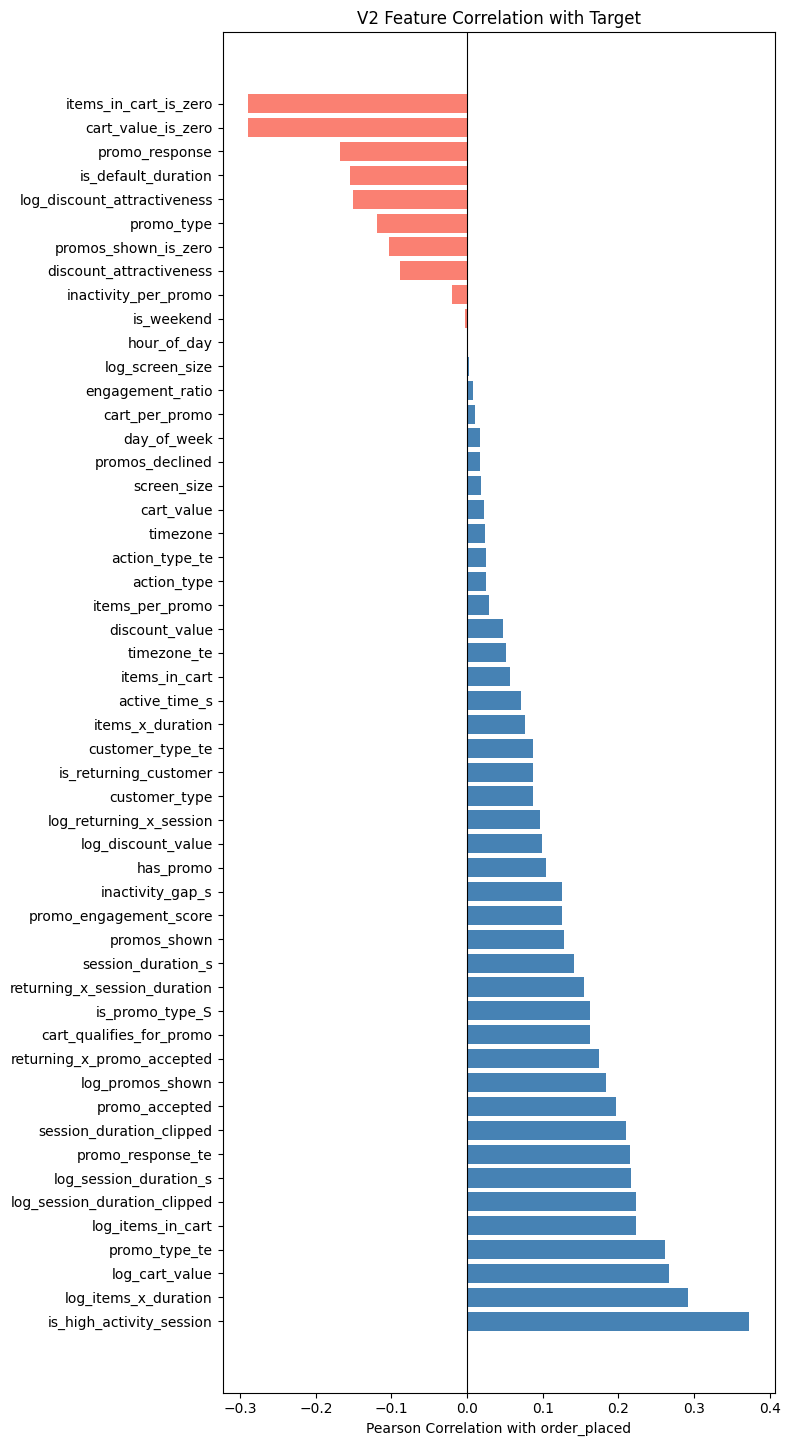

Top 15 correlated features:
is_high_activity_session        0.3733
log_items_x_duration            0.2920
log_cart_value                  0.2664
promo_type_te                   0.2618
log_items_in_cart               0.2232
log_session_duration_clipped    0.2228
log_session_duration_s          0.2167
promo_response_te               0.2156
session_duration_clipped        0.2095
promo_accepted                  0.1968
log_promos_shown                0.1837
returning_x_promo_accepted      0.1744
cart_qualifies_for_promo        0.1628
is_promo_type_S                 0.1626
returning_x_session_duration    0.1548
Name: order_placed, dtype: float64


In [8]:
# ── Full correlation chart of all features ────────────────────────────────
corr_all = train[FEATURE_COLS + ['order_placed']].corr()['order_placed'].drop('order_placed')
corr_all = corr_all.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, len(FEATURE_COLS) * 0.28))
colors = ['steelblue' if v >= 0 else 'salmon' for v in corr_all.values]
ax.barh(corr_all.index, corr_all.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with order_placed')
ax.set_title('V2 Feature Correlation with Target')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_correlation_v2.png'), dpi=150)
plt.show()

print('Top 15 correlated features:')
print(corr_all.head(15).round(4))

## 8. Save

In [9]:
train.to_csv(TRAIN_OUT, index=False)
test.to_csv(TEST_OUT,   index=False)

print(f'✅ Saved train_features_v2.csv → {train.shape}')
print(f'✅ Saved test_features_v2.csv  → {test.shape}')
print(f'\nFeature count: {len(FEATURE_COLS)} total')
print(f'  Phase 2 original  : 17')
print(f'  Phase 3 engineered: 12')
print(f'  V2 additions      : {len(FEATURE_COLS) - 29}')
print(f'\nHand-off to 06_modeling_v2.ipynb')

✅ Saved train_features_v2.csv → (297236, 54)
✅ Saved test_features_v2.csv  → (99639, 53)

Feature count: 52 total
  Phase 2 original  : 17
  Phase 3 engineered: 12
  V2 additions      : 23

Hand-off to 06_modeling_v2.ipynb


## 9. V2 Feature Engineering Summary

| Feature Group | Features Added | Key Insight |
|---|---|---|
| Target encoding | `action_type_te`, `customer_type_te`, `promo_type_te`, `promo_response_te`, `timezone_te` | Encodes actual order rate per category — far richer than label integers |
| Log transforms | `log_session_duration_s`, `log_cart_value`, `log_items_in_cart`, `log_promos_shown`, `log_screen_size`, `log_discount_value` | Reduces skewness (session_duration: 79→~1), improves split quality |
| Zero flags | `cart_value_is_zero`, `items_in_cart_is_zero`, `promos_shown_is_zero` | ~73% zeros in these columns — the zero/non-zero boundary is a critical decision boundary |
| Session outlier handling | `session_duration_clipped`, `log_session_duration_clipped`, `is_default_duration` | Min=1800 (suspicious cap), Max=242K (implausible) — flagged and clipped |
| New ratios | `cart_per_promo`, `inactivity_per_promo`, `items_per_promo` | Normalize engagement by promo exposure |
| Log of interactions | `log_items_x_duration`, `log_returning_x_session`, `log_discount_attractiveness` | Phase 3 interactions were heavily skewed — log-transforming improves their utility |

**Hand-off:** `data/train_features_v2.csv` and `data/test_features_v2.csv` → `06_modeling_v2.ipynb`